## Load Balancer
Load Balancer is a process of distributing incoming network traffic across multiple servers to ensure that no single server is overwhelmed.

By evenly spreading the workload, load balancing aims to prevent overload on a single server, enhance performance by reducing response times and improve availability by rerouting traffic in case of server failures.

There are several algorithms to achieve load balancing, each with its pros and cons.
1. Round Robin: Simple and even distribution, best for homogeneous servers.
2. Weighted Round Robin: Distributes based on server capacity, good for heterogeneous environments.
3. Least Connections: Dynamically balances based on load, ideal for varying workloads.
4. Least Response Time: Optimizes for fastest response, best for environments with varying server performance.
5. IP Hash: Ensures session persistence, useful for stateful applications.

### 1. Round Robin Algorithm

Round robin works when a request is sent to first server in the list, the next request will be going to second server and last server will loop back to the first server.Ensures even distribution of traffic.

#### When to use
When all servers have similar processing capabilities and are equally capable of handling requests.
When simplicity and even distribution of load is more critical. 

#### Drawbacks
1. Does not consider server load or response time.
2. Can lead to inefficiencies if servers have different processing capabilities.

In [2]:
class RoundRobin:
    def __init__(self, servers):
        self.servers = servers
        self.current_index = -1

    def get_next_server(self):
        self.current_index = (self.current_index + 1) % len(self.servers)
        return self.servers[self.current_index]
servers = ["server1", "server2", "server3"]
load_balancer = RoundRobin(servers)

for i in range(6):
    server = load_balancer.get_next_server()
    print(f"Request {i+1} -> {server}")

Request 1 -> server1
Request 2 -> server2
Request 3 -> server3
Request 4 -> server1
Request 5 -> server2
Request 6 -> server3


### 2. Weighted Round Robin
Each server is assigned a weight based on their processing power or available resources.
Servers with higher weights receive a proportionally larger share of incoming requests.

#### When to use:
When servers have different processing capabilities or available resources.
When you want to distribute the load based on the capacity of each server.

Drawbacks:
1. Slightly more complex to implement than simple Round Robin.
2. Does not consider current server load or response time.

In [ ]:
class WeightedRoundRobin:
    """
    Simple Weighted Round Robin.

    Expands each server into the rotation list proportional to its weight.
    server1 (weight=3), server2 (weight=1) → [s1, s1, s1, s2]
    Then plain round robin runs over the expanded list.

    Drawback: sends 3 consecutive requests to server1 before moving on.
    See SmoothWeightedRoundRobin below for a more even distribution.
    """

    def __init__(self, servers: dict[str, int]):
        """
        :param servers: {server_name: weight}  e.g. {"s1": 3, "s2": 1}
        """
        self.rotation = []
        for server, weight in servers.items():
            self.rotation.extend([server] * weight)
        self.current_index = -1

    def get_next_server(self) -> str:
        self.current_index = (self.current_index + 1) % len(self.rotation)
        return self.rotation[self.current_index]


# ---------------------------------------------------------------------------

class SmoothWeightedRoundRobin:
    """
    Smooth Weighted Round Robin (Nginx algorithm).

    Avoids sending consecutive requests to the same server by dynamically
    adjusting each server's current_weight on every pick.

    Algorithm per request:
      1. current_weight[i] += weight[i]          for all servers
      2. Pick server with highest current_weight
      3. current_weight[picked] -= total_weight

    Result: requests are spread as evenly as possible across the cycle,
    no server receives multiple requests in a row unless unavoidable.
    """

    def __init__(self, servers: dict[str, int]):
        """
        :param servers: {server_name: weight}
        """
        self.servers = list(servers.keys())
        self.weights = [servers[s] for s in self.servers]
        self.current_weights = [0] * len(self.servers)
        self.total_weight = sum(self.weights)

    def get_next_server(self) -> str:
        # Step 1: increase each server's current weight by its static weight
        for i in range(len(self.servers)):
            self.current_weights[i] += self.weights[i]

        # Step 2: pick the server with the highest current weight
        best_index = self.current_weights.index(max(self.current_weights))

        # Step 3: penalise the winner by subtracting total weight
        self.current_weights[best_index] -= self.total_weight

        return self.servers[best_index]


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
servers = {"server1": 3, "server2": 2, "server3": 1}  # total weight = 6
total = sum(servers.values())

print("=== Simple Weighted Round Robin ===")
print(f"  Weights: {servers}  (expanded rotation length = {total})\n")
simple = WeightedRoundRobin(servers)
print(f"  Rotation list: {simple.rotation}\n")
for i in range(total):
    print(f"  Request {i + 1} -> {simple.get_next_server()}")

print()

print("=== Smooth Weighted Round Robin (Nginx) ===")
print(f"  Weights: {servers}\n")
smooth = SmoothWeightedRoundRobin(servers)

print(f"  {'Req':<5} {'Picked':<10} {'current_weights after pick'}")
print(f"  {'-'*50}")
temp = SmoothWeightedRoundRobin(servers)
for i in range(total):
    # Step 1: add weights
    for j in range(len(temp.servers)):
        temp.current_weights[j] += temp.weights[j]
    best = temp.current_weights.index(max(temp.current_weights))
    picked = temp.servers[best]
    temp.current_weights[best] -= temp.total_weight
    weights_display = dict(zip(temp.servers, temp.current_weights))
    print(f"  {i + 1:<5} {picked:<10} {weights_display}")

# Result: s1 → s2 → s1 → s3 → s2 → s1 — server1 picked 3×, server2 2×, server3 1×. Exactly the weights.
# Why server1 doesn't win every time:
# After server1 wins in Req 1, it gets penalised by -6, dropping to -3. 
# Now server2 and server3 keep accumulating weight each round without being penalised, 
# so they overtake server1 and win before server1 can recover.

### 3. Least Connections

Monitor the number of active connections on each server.
Assigns incoming requests to the server with the least number of active connections.

##### When to Use it
When you want to distribute the load based on the current number of active connections.
When servers have similar processing capabilities but may have different levels of concurrent connections.
Helps prevent any server from becoming overloaded with a high number of active connections

Drawbacks:
1. May not be optimal if servers have different processing capabilities.
2. Requires tracking active connections for each server.

In [ ]:
import threading
import time
import random


class LeastConnections:
    """
    Least Connections load balancer.

    Routes each new request to the server with the fewest active connections.
    When a request completes, the connection count for that server is decremented.

    Better than Round Robin when requests have varying processing times —
    a slow server naturally accumulates connections and receives fewer new ones.
    """

    def __init__(self, servers: list[str]):
        self.servers = servers
        # Active connection count per server
        self.connections: dict[str, int] = {s: 0 for s in servers}
        self._lock = threading.Lock()

    def get_next_server(self) -> str:
        with self._lock:
            # Pick the server with the fewest active connections
            # min() is stable: ties go to the first server in the list
            server = min(self.connections, key=lambda s: self.connections[s])
            self.connections[server] += 1
            return server

    def release(self, server: str) -> None:
        """Call when a request finishes to decrement the connection count."""
        with self._lock:
            if self.connections[server] > 0:
                self.connections[server] -= 1

    def snapshot(self) -> dict[str, int]:
        with self._lock:
            return dict(self.connections)


# ---------------------------------------------------------------------------
# Demo 1: static routing — show that least-loaded server is always picked
# ---------------------------------------------------------------------------
lb = LeastConnections(["server1", "server2", "server3"])

print("=== Static routing (no releases) ===")
print(f"  {'Req':<5} {'Picked':<10} {'Connections'}")
print(f"  {'-'*45}")
for i in range(9):
    server = lb.get_next_server()
    print(f"  {i+1:<5} {server:<10} {lb.snapshot()}")

# ---------------------------------------------------------------------------
# Demo 2: dynamic routing — connections are released as requests finish
# ---------------------------------------------------------------------------
print("\n=== Dynamic routing (requests complete at different speeds) ===\n")

lb2 = LeastConnections(["server1", "server2", "server3"])

# Simulate varying request durations:
# server1 is slow (holds connections longer), server2/server3 are fast
request_log = []

def handle_request(request_id: int, duration: float):
    server = lb2.get_next_server()
    request_log.append(f"  Req {request_id:>2} → {server}  (duration={duration:.1f}s)  conns={lb2.snapshot()}")
    time.sleep(duration)
    lb2.release(server)

threads = []
durations = [0.3, 0.1, 0.1, 0.3, 0.1, 0.3, 0.1, 0.1]

for i, dur in enumerate(durations):
    t = threading.Thread(target=handle_request, args=(i + 1, dur))
    threads.append(t)
    t.start()
    time.sleep(0.05)   # slight stagger so routing decisions are visible

for t in threads:
    t.join()

for line in request_log:
    print(line)

print(f"\n  Final connection counts: {lb2.snapshot()}")


### 4. Least Response Time

Routes each request to the server with the lowest combination of active connections and response time.
Builds on Least Connections by also factoring in how fast each server is responding — a server with few connections but high latency is deprioritised over a slightly busier but faster one.

#### When to use
When servers have different hardware or are under varying load and response times differ significantly.
When minimising end-user latency is the primary goal.

#### Drawbacks
1. Requires tracking response times, adding overhead.
2. Response time measurements can be noisy — a single slow request can skew routing decisions.


In [ ]:
import threading
import time


class LeastResponseTime:
    """
    Least Response Time load balancer.

    Scores each server as:
        score = active_connections * avg_response_time

    The server with the lowest score gets the next request.
    A server with no history (avg_response_time=0) scores 0 and is always
    tried first — this bootstraps new or recovered servers naturally.
    """

    def __init__(self, servers: list[str]):
        self.servers = servers
        self.connections: dict[str, int] = {s: 0 for s in servers}
        self.avg_response_time: dict[str, float] = {s: 0.0 for s in servers}
        self.request_count: dict[str, int] = {s: 0 for s in servers}
        self._lock = threading.Lock()

    def _score(self, server: str) -> float:
        """Lower is better. Unvisited servers score 0 (highest priority)."""
        return self.connections[server] * self.avg_response_time[server]

    def get_next_server(self) -> str:
        with self._lock:
            server = min(self.servers, key=self._score)
            self.connections[server] += 1
            return server

    def release(self, server: str, response_time: float) -> None:
        """
        Call when a request finishes.
        Updates the rolling average response time using an incremental formula:
            new_avg = old_avg + (new_value - old_avg) / total_count
        This avoids storing all past response times.
        """
        with self._lock:
            self.connections[server] = max(0, self.connections[server] - 1)
            self.request_count[server] += 1
            n = self.request_count[server]
            # Incremental (online) mean — no list of past values needed
            self.avg_response_time[server] += (
                response_time - self.avg_response_time[server]
            ) / n

    def snapshot(self) -> dict:
        with self._lock:
            return {
                s: {
                    "conns": self.connections[s],
                    "avg_ms": round(self.avg_response_time[s] * 1000, 1),
                    "score": round(self._score(s), 4),
                }
                for s in self.servers
            }


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
lb = LeastResponseTime(["server1", "server2", "server3"])

# Simulate servers with different characteristic response times
RESPONSE_PROFILES = {
    "server1": 0.30,   # slow
    "server2": 0.05,   # fast
    "server3": 0.15,   # medium
}

print("=== Least Response Time ===\n")
print(f"  Server profiles: { {s: f'{int(v*1000)}ms' for s, v in RESPONSE_PROFILES.items()} }\n")
print(f"  {'Req':<5} {'Picked':<10} {'State after routing'}")
print(f"  {'-'*65}")

def handle(req_id: int):
    server = lb.get_next_server()
    duration = RESPONSE_PROFILES[server] + (0.02 * (req_id % 3))  # slight jitter
    print(f"  {req_id:<5} {server:<10} {lb.snapshot()}")
    time.sleep(duration)
    lb.release(server, duration)

threads = []
for i in range(1, 10):
    t = threading.Thread(target=handle, args=(i,))
    threads.append(t)
    t.start()
    time.sleep(0.08)  # stagger requests so decisions are visible

for t in threads:
    t.join()

print(f"\n  Final state: {lb.snapshot()}")
print("\n  → server2 (fastest) should receive the most requests")


### 5. IP Hash

Routes each client to the same server every time by hashing their IP address.
The hash is stable — the same IP always maps to the same server — giving session persistence without storing session state in the load balancer.

#### When to use
When the application is stateful and a client must always reach the same server (e.g. shopping cart stored in server memory, WebSocket connections).
When you want sticky sessions without a separate session store.

#### Drawbacks
1. Uneven distribution if a small number of IPs generate most traffic.
2. When a server is added or removed, hashes shift and existing clients may be remapped.
   Consistent hashing mitigates this (only ~1/N clients remap on a node change).


In [ ]:
import hashlib


class IPHash:
    """
    IP Hash load balancer.

    Hashes the client IP to an integer, then maps it to a server via modulo.
    The same IP always lands on the same server — session persistence with
    zero state stored in the load balancer.
    """

    def __init__(self, servers: list[str]):
        self.servers = servers

    def _hash(self, ip: str) -> int:
        """SHA-256 of the IP, take first 8 bytes as an integer."""
        return int(hashlib.sha256(ip.encode()).hexdigest()[:8], 16)

    def get_server(self, client_ip: str) -> str:
        index = self._hash(client_ip) % len(self.servers)
        return self.servers[index]


class ConsistentHashIPHash:
    """
    IP Hash with Consistent Hashing.

    Places both servers and IPs on a virtual ring of 2^32 positions.
    Each IP maps to the first server clockwise from its position.

    Benefit over plain modulo: adding or removing a server only remaps
    ~1/N of clients instead of reshuffling all of them.

    virtual_nodes: number of positions per real server on the ring.
    More virtual nodes → more even distribution but more memory.
    """

    def __init__(self, servers: list[str], virtual_nodes: int = 100):
        self.virtual_nodes = virtual_nodes
        self.ring: dict[int, str] = {}
        self.sorted_keys: list[int] = []
        for server in servers:
            self._add_server(server)

    def _hash(self, key: str) -> int:
        return int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)

    def _add_server(self, server: str) -> None:
        for i in range(self.virtual_nodes):
            key = self._hash(f"{server}:vnode:{i}")
            self.ring[key] = server
        self.sorted_keys = sorted(self.ring.keys())

    def remove_server(self, server: str) -> None:
        for i in range(self.virtual_nodes):
            key = self._hash(f"{server}:vnode:{i}")
            del self.ring[key]
        self.sorted_keys = sorted(self.ring.keys())

    def get_server(self, client_ip: str) -> str:
        h = self._hash(client_ip)
        # Find the first ring position >= h (clockwise)
        for key in self.sorted_keys:
            if h <= key:
                return self.ring[key]
        # Wrap around: if h is past all positions, use the first one
        return self.ring[self.sorted_keys[0]]


# ---------------------------------------------------------------------------
# Demo 1: IP Hash (plain modulo)
# ---------------------------------------------------------------------------
servers = ["server1", "server2", "server3"]
lb = IPHash(servers)

client_ips = ["192.168.1.1", "10.0.0.5", "172.16.0.8", "192.168.1.2", "10.0.0.5"]

print("=== IP Hash (plain modulo) ===\n")
for ip in client_ips:
    print(f"  {ip:<16} → {lb.get_server(ip)}")

print("\n  Same IP always maps to the same server.")

# ---------------------------------------------------------------------------
# Demo 2: Consistent Hashing — show minimal remapping on server change
# ---------------------------------------------------------------------------
print("\n=== Consistent Hashing — server removed ===\n")

test_ips = [f"10.0.{i}.{j}" for i in range(3) for j in range(1, 6)]

ch_before = ConsistentHashIPHash(servers)
mapping_before = {ip: ch_before.get_server(ip) for ip in test_ips}

ch_after = ConsistentHashIPHash(servers)
ch_after.remove_server("server3")
mapping_after = {ip: ch_after.get_server(ip) for ip in test_ips}

remapped = [ip for ip in test_ips if mapping_before[ip] != mapping_after[ip]]
stable   = [ip for ip in test_ips if mapping_before[ip] == mapping_after[ip]]

print(f"  Total clients : {len(test_ips)}")
print(f"  Remapped      : {len(remapped)}  ({100*len(remapped)/len(test_ips):.0f}%)  ← ~1/N expected")
print(f"  Stable        : {len(stable)}  ({100*len(stable)/len(test_ips):.0f}%)")
print(f"\n  Plain modulo would remap ~{100*(len(servers)-1)//len(servers)}% on removing 1 of {len(servers)} servers.")


![Screenshot 2026-04-15 at 2.48.47 PM.png](<attachment:Screenshot 2026-04-15 at 2.48.47 PM.png>)
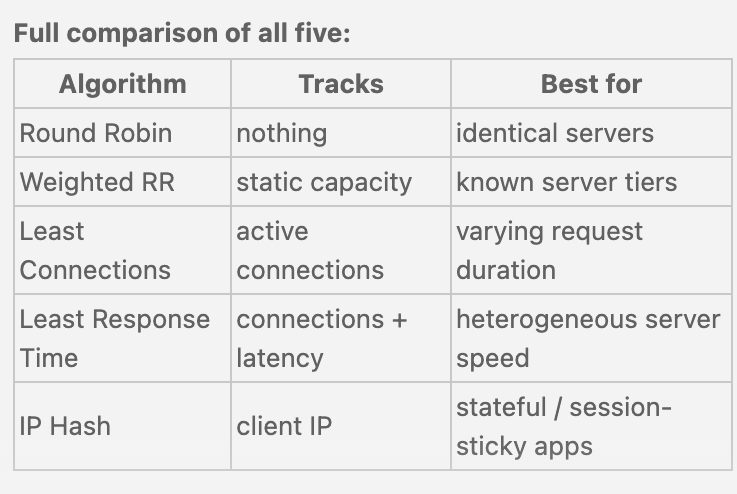